# Shark attacks. OceanTrust.

## Index
- [First look at the Data](#first-look-at-the-data)
- [Cleaning Process](#cleaning-process)
    - [Date and Year](#date-and-year)
    - [Country, State, Location and Sex](#country-state-location-and-sex)
    - [Type, Activity, Species, Age and Injury](#type-activity-species-age-and-injury)
        - [Type Clean](#type-clean)
        - [Activity Clean](#activity-clean)
        - [Species Clean](#species-clean)
        - [Age Clean](#age-clean)
        - [Injury Clean](#injury-clean)
- [Merging Datasets](#merging-datasets)
- [Exploratory Data Analysis](#exploratory-data-analysis)
    - [Data Quality Check](#data-quality-check)
    - [Exploring the Data](#exploring-the-data)
- [Hypothesis Validation](#hypothesis-validation)
- [Creating the visualizations](#creating-the-visualizations)

We tried making an index with links to the sections. It isn't working, but, at least, we have an index :)).

## First look at the Data

In [2]:
import numpy as np
import pandas as pd

df = pd.DataFrame(pd.read_csv("shark_attacks.csv"))

df.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,Unknown,M,39,...,Great White Shark,US Sun: Mendocino Coast News:Melissa Michaelson:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,Unknown,F,?,...,Unknown shark 5ft (1.5m),People Magazine: Kevin McMurray Trackingsharks...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,Dave Daniell,M,?,...,Great White Shark 10ft (3m),Perth Now: Kevin McMurray Trackingsharks.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,Unknown,M,50's,...,Unknown,News.com.au: ABC News: Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,Cyril Chevalier,M,55,...,Tiger or bull shark implicated,Johannes Marchand: Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print(df.shape)
print("\n")
print(df.columns)
print("\n")
print(df.nunique())
print("\n")
print(df.info())
print("\n")
print(df.dtypes)

(7082, 23)


Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='str')


Date              6091
Year               261
Type                13
Country            253
State              946
Location          4626
Activity          1612
Name              5797
Sex                 11
Age                178
Injury            4193
Fatal Y/N           12
Time               476
Species           1744
Source            5409
pdf               6789
href formula      6784
href              6776
Case Number       6777
Case Number.1     6775
original order    6797
Unnamed: 21          1
Unnamed: 22          2
dtype: int64


<class 'pandas.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype 

In [4]:
print(df["Sex"].unique())
print("\n")
print(df["Unnamed: 21"].unique())
print("\n")
print(df["Unnamed: 22"].unique())
print("\n")
print(df["Fatal Y/N"].unique())
print("\n")
print(df["Type"].unique())
print("\n")
print(df["Time"].unique())

# we are checking columns that we don't know what info they have (e.g. "Unnamed: 21") 
# or that have more unique values than expected (e.g. "Sex" was expected to have 2 and has 11)

<ArrowStringArray>
['M', 'F', 'M ', '?', 'F ', nan, ' M', 'm', 'lli', 'M x 2', 'N', '.']
Length: 12, dtype: str


<ArrowStringArray>
[nan, 'stopped here']
Length: 2, dtype: str


<ArrowStringArray>
[nan, 'Teramo', 'change filename']
Length: 3, dtype: str


<ArrowStringArray>
['N', 'Y', 'F', 'M', nan, 'n', 'Nq', 'UNKNOWN', '2017', 'Y x 2', ' N', 'N ',
 'y']
Length: 13, dtype: str


<ArrowStringArray>
[         'Unprovoked',            'Provoked',        'Questionable',
          'unprovoked',           ' Provoked',          'Watercraft',
        'Sea Disaster',                   nan,                   '?',
         'Unconfirmed',          'Unverified',             'Invalid',
 'Under investigation',                'Boat']
Length: 14, dtype: str


<ArrowStringArray>
[        '1715hrs',         '1015hrs',         '0800hrs',         '0815hrs',
               '?',         '1100hrs',         '1815hrs',         '0830hrs',
         '1145hrs',         '1820hrs',
 ...
 '"Early evening"',  'Late A

In [5]:
print (df["Date"][-30:-1])
print (df["Year"][-30:-1])
print (df["Date"][0:30])

# we wanted to check why there were two columns that could be together and that sometimes have redundant data

7052                                         World War II
7053                                          Before 1905
7054                              A few years before 1938
7055                                              No date
7056                                          Early 1930s
7057                                          Before 1927
7058                                  Between 1918 & 1939
7059                                              No date
7060                                              No date
7061                                              No date
7062                                           1920 -1923
7063                                          Before 1921
7064                                          Before 1911
7065                                          Before 1921
7066                                          Before 1921
7067                                          Before 1917
7068                                   Before 17-Jul-1916
7069    No dat

We took a look at the columns and decided that for our project, the most interesting ones would be:
- The dataset contains 7082 rows and 23 columns, which is relatively large and suitable for analysis.
- There are several columns with unclear or redundant information, such as:
    - pdf, href, href formula
    - Unnamed: 21, Unnamed: 22
- Some columns seem duplicated or very similar, e.g.:
    - Case Number and Case Number.1
- The dataset contains a mix of data types:
    - Numerical (e.g. Year)
    - Categorical (e.g. Country, Type)
    - Text-heavy columns (e.g. Activity, Species)
- Several columns contain missing values (NaN).
- Some variables show inconsistent formats, for example:
    - Age contains values like numbers, ranges, and text (e.g. “50s”, “?”)
    - Species contains inconsistent naming (e.g. “Great White Shark”, “Unknown”)
    - The dataset appears to be messy and requires cleaning before analysis.

## Cleaning Process

We divided this process, that's why there are different kinds of cleaning. But, don't worry! With this comments everything will be super clear and you'll follow every step and won't feel lost.
During this cleaning, we couldn't drop rows. The idea was to keep the useful columns for us, try to standarize the values in some of them so that they are ready for the EDA. 

### Date and Year

In [6]:
dt_df = df
# create a DataFrame for DateTime 

dt_df.columns

Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='str')

In [7]:
dt_df = dt_df.drop(columns = ['Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'])

# drop columns we don't want

In [8]:
dt_df.columns = dt_df.columns.str.lower()

# standarize names

In [9]:
dt_df.head()

,date,year
0,18th March,2026.0
1,14th March,2026.0
2,10th March,2026.0
3,5th March,2026.0
4,22nd February,2026.0


In [10]:
print (dt_df.isnull().sum())
print ("\n")
print (dt_df.dtypes)

# almost no null values, but two different data types

date    0
year    2
dtype: int64


date        str
year    float64
dtype: object


In [11]:
dt_df["year"] = dt_df["year"].fillna(0.0)
# the 2 null values will be replaced for a float number so we can change the datatype

dt_df["year"] = dt_df["year"].apply(lambda year: str(int(year)))
# we use apply to change float to integer (we remove decimals, not useful for years), then to string

dt_df["full_date"] = dt_df["date"] + " " +dt_df["year"]
# create a new column that sums both strings

In [12]:
dt_df.head()

,date,year,full_date
0,18th March,2026,18th March 2026
1,14th March,2026,14th March 2026
2,10th March,2026,10th March 2026
3,5th March,2026,5th March 2026
4,22nd February,2026,22nd February 2026


In [13]:
dt_df.dtypes

date         str
year         str
full_date    str
dtype: object

In [14]:
print(dt_df["full_date"][5000])
print(dt_df["full_date"][400])
print(dt_df["full_date"][3000])
print(dt_df["full_date"][100])
print(dt_df["full_date"][2000])
print(dt_df["full_date"][10])

# we tried to find different ways in which data was recorded

15-Aug-1956 1956
26-Jun-2021 2021
09-Jun-1997 1997
2024-09-17 00:00:00 2024
07-Jun-2008 2008
19th January 2026


In [15]:
dt_df["full_date"] = dt_df["full_date"].str.replace("-", " ", regex = False)
dt_df["full_date"] = dt_df["full_date"].str.replace("(?<=\d)st|(?<=\d)nd|(?<=\d)rd|(?<=\d)th|Before|Reported|reported", "", regex = True)

# we tried to remove almost everything that wasn't letting us format dates
# we removed the terminations as "th" and the "-"
# (?<=\d) this means only if it comes after a digit. we realised we were removing auguST

def remove_str(string):
    """
    Takes a string as a paramenter. 
    It splits strings and keep the 3 first strings if they have more than that. 
    If not it keeps it at it is. 
    """
    split = string.split()
    if len(split) >= 4:
        split = string.split()
        new_string = split[0] + " " + split[1] + " " + split[2]
        return new_string
    else: 
        return string

# we realised there were sometimes where we duplicated the year when adding the two columns, so we splited the string and removed the last part.

dt_df["full_date"] = dt_df["full_date"].apply(remove_str)

In [16]:
format1 = pd.to_datetime(dt_df["full_date"], format="%d %B %Y", errors="coerce")
format2 = pd.to_datetime(dt_df["full_date"], format="%Y %m %d", errors="coerce")
format3 = pd.to_datetime(dt_df["full_date"], format="%d %b %Y", errors="coerce")

# here we are using to_datetime to format all the dates.
# we saw three different formats. Changes were done on the order of the day-month-year, but also on how the month appeared
# sometimes as number, sometimes whole word, sometimes abbreviation.
# the errors = "coerce" keeps the formatting going on even though it runs with different formats
# we are making three different lists/series. each of them will format certain kinds of dates and will put null values to the rest

dt_df["final_date"] = format1.fillna(format2).fillna(format3)

# we make a new column with the final output. We are mixing like the three series, they won't collapse 
# because they have the same number of rows and they maintain the original order. 
# so they will overwrite in case there is a null value and they have a different value for that row.

In [17]:
dt_df.head(50)

,date,year,full_date,final_date
0,18th March,2026,18 March 2026,2026-03-18
1,14th March,2026,14 March 2026,2026-03-14
2,10th March,2026,10 March 2026,2026-03-10
3,5th March,2026,5 March 2026,2026-03-05
4,22nd February,2026,22 February 2026,2026-02-22
5,6th February,2026,6 February 2026,2026-02-06
6,29th January,2026,29 January 2026,2026-01-29
7,29th January,2026,29 January 2026,2026-01-29
8,24th January,2026,24 January 2026,2026-01-24
9,20th January,2026,20 January 2026,2026-01-20


In [18]:
dt_df.tail(10)

,date,year,full_date,final_date
7072,Circa 1862,0,Circa 1862 0,NaT
7073,Before 1906,0,1906 0,NaT
7074,Before 1906,0,1906 0,NaT
7075,Before 1906,0,1906 0,NaT
7076,Before 1906,0,1906 0,NaT
7077,Before 1903,0,1903 0,NaT
7078,Before 1903,0,1903 0,NaT
7079,1900-1905,0,1900 1905 0,NaT
7080,1883-1889,0,1883 1889 0,NaT
7081,1845-1853,0,1845 1853 0,NaT


In [19]:
dt_df.isna().sum()

# as you can see we have almost 1000 null values. But for the analysis we are using most recent events. 
# We assume that most of them are the oldest records that were the ones with most incosistencies

date            0
year            0
full_date       0
final_date    937
dtype: int64

### Country, State, Location and Sex

In [20]:
csls_df = df

# we repeat the process for country, state, location and sex.

In [21]:
csls_df.columns

Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='str')

In [22]:
csls_df = csls_df.drop(columns = ['Date', 'Year', 'Type', 'Activity',
       'Name', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'])

In [23]:
csls_df.columns = csls_df.columns.str.lower()

# lower the strings to standarize

In [24]:
csls_df.head()

,country,state,location,sex
0,USA,California,Big River Beach Mendocino County,M
1,Australia,Western Australia,Exmouth,F
2,Australia,Western Australia,Exmouth,M
3,Australia,Queensland,Lady Elliott Island,M
4,New Caledonia,Noumea,Anse Vata near Point Magnin,M


In [25]:
print(csls_df.isnull().sum())
print ("\n")
print(csls_df.dtypes)

country      50
state       487
location    567
sex         578
dtype: int64


country     str
state       str
location    str
sex         str
dtype: object


In [26]:
csls_df["sex"].value_counts()

# we have to standarize this. there are several misspelling mistakes.
# we decided discarding the rest because the sample is little

sex
M        5678
F         810
M           5
?           2
F           2
N           2
 M          1
m           1
lli         1
M x 2       1
.           1
Name: count, dtype: int64

In [27]:
sex_mapping = { "M" : "M",
                "F" : "F",
                "M " : "M",
                "F " : "F",
                " M" : "M",
                "m" : "M",
}

# we decided discarding the rest because the sample is little
# we used map function for this. it goes over the whole column and change values based on the key:value pairs in the dict

csls_df["sex"] = csls_df["sex"].map(sex_mapping)

In [28]:
print (csls_df["sex"].value_counts())
print ("null values: ", csls_df["sex"].isnull().sum())

# more or less same numbers but now just two different values + null ones

sex
M    5685
F     812
Name: count, dtype: int64
null values:  585


In [29]:
print (csls_df.dropna (subset = ["country", "state", "location"], thresh = 3).shape)
print (csls_df.dropna (subset = ["country", "state", "location"], thresh = 3).isna().sum())
print ("\n")
print (csls_df.dropna (subset = ["country", "state", "location"], thresh = 2).shape)
print (csls_df.dropna (subset = ["country", "state", "location"], thresh = 2).isna().sum())
print ("\n")
print (csls_df.dropna (subset = ["state", "location"], thresh = 2).shape)
print (csls_df.dropna (subset = ["state", "location"], thresh = 2).isna().sum())

# We were checking if the missing values regarding geography were related. 
# In the end, these didn't have a lot of relevance. Standarizing the three columns now didn't make sense.
# so, we did just some superficial work

(6274, 4)
country       0
state         0
location      0
sex         481
dtype: int64


(6815, 4)
country       5
state       230
location    306
sex         556
dtype: int64


(6279, 4)
country       5
state         0
location      0
sex         482
dtype: int64


In [31]:
for country in csls_df["country"].unique():
    print (country)

USA
Australia
New Caledonia
Cayman Islands
Brazil
US Virgin Islands
Mozambique
French Polynesia
Samoa
Columbia
Costa Rica
Bahamas
Puerto Rico
Spain
Canary Islands
South Africa
Vanuatu
Jamaica
Israel
Mexico
Maldives
Philippines
Turks and Caicos
Egypt
Thailand
New Zealand
Hawaii
Honduras
Indonesia
Morocco
Belize
Maldive Islands
Tobago
AUSTRALIA
INDIA
TRINIDAD
BAHAMAS
SOUTH AFRICA
MEXICO
NEW ZEALAND
EGYPT
BELIZE
PHILIPPINES
Coral Sea
SPAIN
PORTUGAL
SAMOA
COLOMBIA
ECUADOR
FRENCH POLYNESIA
NEW CALEDONIA
TURKS and CaICOS
CUBA
BRAZIL
SEYCHELLES
ARGENTINA
FIJI
MeXICO
ENGLAND
JAPAN
INDONESIA
JAMAICA
MALDIVES
THAILAND
COLUMBIA
COSTA RICA
British Overseas Territory
CANADA
JORDAN
ST KITTS / NEVIS
ST MARTIN
PAPUA NEW GUINEA
REUNION ISLAND
ISRAEL
CHINA
IRELAND
ITALY
MALAYSIA
LIBYA
nan
MAURITIUS
SOLOMON ISLANDS
ST HELENA, British overseas territory
COMOROS
REUNION
UNITED KINGDOM
UNITED ARAB EMIRATES
CAPE VERDE
Fiji
DOMINICAN REPUBLIC
CAYMAN ISLANDS
ARUBA
MOZAMBIQUE
PUERTO RICO
ATLANTIC OCEAN
GREECE
S

In [32]:
def lowletters(word):
    """
    takes a word. It lowers the letters and replaces interrogation marks and strips.
    """
    str_word =str(word)
    return str_word.lower().replace("?", "").strip()

# there were different formatting, some ? and we strip just in case.

In [33]:
csls_df["country"] = csls_df["country"].apply(lowletters)
csls_df["country"].value_counts().head(20)

#we are going to apply the same process to the three columns

country
usa                 2580
australia           1526
south africa         599
new zealand          146
bahamas              141
papua new guinea     136
brazil               123
mexico               107
italy                 72
fiji                  70
new caledonia         68
philippines           65
reunion               60
egypt                 53
mozambique            52
nan                   50
cuba                  49
spain                 47
india                 41
french polynesia      40
Name: count, dtype: int64

In [34]:
csls_df["state"] = csls_df["state"].apply(lowletters)
csls_df["state"].value_counts().head(20)  

state
florida                  1193
new south wales           523
nan                       487
queensland                355
hawaii                    345
california                328
western australia         244
kwazulu-natal             219
western cape province     197
south carolina            176
eastern cape province     168
north carolina            122
south australia           120
victoria                   98
texas                      83
pernambuco                 80
north island               76
torres strait              72
new jersey                 57
new york                   48
Name: count, dtype: int64

In [35]:
csls_df["location"] = csls_df["location"].apply(lowletters)
csls_df["location"].value_counts().head(20)  

location
nan                                              567
new smyrna beach, volusia county                 193
daytona beach, volusia county                     34
ponce inlet, volusia county                       28
myrtle beach, horry county                        22
melbourne beach, brevard county                   21
cocoa beach, brevard  county                      19
durban                                            18
isle of palms, charleston county                  16
piedade                                           14
boa viagem, recife                                14
cocoa beach, brevard county                       13
jensen beach, martin county                       13
jacksonville beach, duval county                  13
juno beach, palm beach county                     12
ponce inlet, new smyrna beach, volusia county     12
ormond beach, volusia county                      11
palm beach, palm beach county                     11
mossel bay                           

In [36]:
csls_df.head()

,country,state,location,sex
0,usa,california,big river beach mendocino county,M
1,australia,western australia,exmouth,F
2,australia,western australia,exmouth,M
3,australia,queensland,lady elliott island,M
4,new caledonia,noumea,anse vata near point magnin,M


### Activity, Type, Species, Age and Injury

In [37]:
df.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,Unknown,M,39,...,Great White Shark,US Sun: Mendocino Coast News:Melissa Michaelson:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,Unknown,F,?,...,Unknown shark 5ft (1.5m),People Magazine: Kevin McMurray Trackingsharks...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,Dave Daniell,M,?,...,Great White Shark 10ft (3m),Perth Now: Kevin McMurray Trackingsharks.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,Unknown,M,50's,...,Unknown,News.com.au: ABC News: Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,Cyril Chevalier,M,55,...,Tiger or bull shark implicated,Johannes Marchand: Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
df.columns

Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='str')

In [40]:
df.columns = df.columns.str.strip()

In [41]:
df[["Activity", "Type", "Species", "Age", "Injury"]].head()

,Activity,Type,Species,Age,Injury
0,Surfing,Unprovoked,Great White Shark,39,Injuries to both legs and feet
1,Swimming,Unprovoked,Unknown shark 5ft (1.5m),?,Minor injuries
2,Wing Foiling,Unprovoked,Great White Shark 10ft (3m),?,None reported damage to board
3,Snorkeling,Unprovoked,Unknown,50's,Lacerations elbow and abdomen
4,Wing Foiling,Unprovoked,Tiger or bull shark implicated,55,Deep wounds arms and legs


In [42]:
df_work = df[["Activity", "Type", "Species", "Age", "Injury"]].copy()

# in this case, instead of moving everything to a new variable and dropping columns
# we copy the part of the DF we need to a new variable

In [43]:
df_work.info()

<class 'pandas.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Activity  6499 non-null   str  
 1   Type      7064 non-null   str  
 2   Species   3951 non-null   str  
 3   Age       4088 non-null   str  
 4   Injury    7047 non-null   str  
dtypes: str(5)
memory usage: 756.9 KB


In [44]:
df_work.isna().sum()

Activity     583
Type          18
Species     3131
Age         2994
Injury        35
dtype: int64

#### Type Clean

In [45]:
df_work["Type"].value_counts(dropna=False)

Type
Unprovoked             5233
Provoked                642
Invalid                 552
Watercraft              355
Sea Disaster            242
Questionable             26
NaN                      18
Boat                      7
 Provoked                 2
unprovoked                1
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64

In [46]:
df_work["Type_clean"] = df_work["Type"].str.lower()
df_work["Type_clean"].value_counts(dropna=False)

# we format strings and create a new column with them

Type_clean
unprovoked             5234
provoked                642
invalid                 552
watercraft              355
sea disaster            242
questionable             26
NaN                      18
boat                      7
 provoked                 2
?                         1
unconfirmed               1
unverified                1
under investigation       1
Name: count, dtype: int64

In [47]:
df_work["Type_final"] = df_work["Type_clean"].apply(
    lambda x: x if x in ["unprovoked", "provoked"] else "other"
)

df_work["Type_final"].value_counts(dropna=False)

# we decided to work only with unprovoked-provoked as there were some scenarios that we weren't covering as sea disaster.
# there were other ambiguous as questionable or unconfirmed

Type_final
unprovoked    5234
other         1206
provoked       642
Name: count, dtype: int64

In [48]:
df_work.columns

Index(['Activity', 'Type', 'Species', 'Age', 'Injury', 'Type_clean',
       'Type_final'],
      dtype='str')

In [49]:
df_work = df_work.drop (columns = ['Type', 'Type_clean'])

# we drop those column and keep the final one

In [50]:
df_work.head()

,Activity,Species,Age,Injury,Type_final
0,Surfing,Great White Shark,39,Injuries to both legs and feet,unprovoked
1,Swimming,Unknown shark 5ft (1.5m),?,Minor injuries,unprovoked
2,Wing Foiling,Great White Shark 10ft (3m),?,None reported damage to board,unprovoked
3,Snorkeling,Unknown,50's,Lacerations elbow and abdomen,unprovoked
4,Wing Foiling,Tiger or bull shark implicated,55,Deep wounds arms and legs,unprovoked


#### Activity Clean

In [51]:
df_work["Activity"].value_counts().head(20)

# we are about to do the same we already did with type. 
# there are a lot of different activities, so we want to put them in just a few groups
# for that, we took the top 20 activities

Activity
Surfing            1149
Swimming           1014
Fishing             494
Spearfishing        391
Wading              178
Bathing             164
Diving              150
Snorkeling          135
Standing            113
Scuba diving         84
Body boarding        63
Body surfing         50
Swimming             47
Boogie boarding      42
Kayaking             40
Free diving          33
Treading water       33
Fell overboard       32
Pearl diving         32
Windsurfing          20
Name: count, dtype: int64

In [52]:
df_work["Activity_clean"] = df_work["Activity"].str.lower().str.strip()
df_work["Activity_clean"].value_counts().head(20)

Activity_clean
surfing            1154
swimming           1061
fishing             510
spearfishing        399
wading              178
bathing             167
diving              153
snorkeling          136
standing            115
scuba diving        106
body boarding        70
boogie boarding      60
body surfing         55
kayaking             43
free diving          35
treading water       33
fell overboard       33
pearl diving         32
surf skiing          24
windsurfing          20
Name: count, dtype: int64

In [53]:
def clean_activity(x):
    """
    It takes a string and group return an output following the type of activity it is. 
    """
    if x in ["surfing", "body surfing", "body boarding", "boogie boarding", "windsurfing", "surf skiing"]:
        return "surfing"
    
    elif x in ["swimming", "bathing", "wading", "standing", "treading water"]:
        return "swimming"
    
    elif x in ["fishing", "spearfishing"]:
        return "fishing"
    
    elif x in ["diving", "scuba diving", "free diving", "snorkeling", "pearl diving"]:
        return "diving"
    
    else:
        return "other"

# these are the groups

In [54]:
df_work["Activity_final"] = df_work["Activity_clean"].apply(clean_activity)
df_work["Activity_final"].value_counts()

Activity_final
other       2774
swimming    1554
surfing     1383
fishing      909
diving       462
Name: count, dtype: int64

In [55]:
df_work = df_work.drop (columns = ["Activity", "Activity_clean"])

In [56]:
df_work.head()

,Species,Age,Injury,Type_final,Activity_final
0,Great White Shark,39,Injuries to both legs and feet,unprovoked,surfing
1,Unknown shark 5ft (1.5m),?,Minor injuries,unprovoked,swimming
2,Great White Shark 10ft (3m),?,None reported damage to board,unprovoked,other
3,Unknown,50's,Lacerations elbow and abdomen,unprovoked,diving
4,Tiger or bull shark implicated,55,Deep wounds arms and legs,unprovoked,other


In [57]:
df_work.groupby("Activity_final")["Type_final"].value_counts()

Activity_final  Type_final
diving          unprovoked     382
                other           45
                provoked        35
fishing         unprovoked     460
                provoked       266
                other          183
other           unprovoked    1680
                other          786
                provoked       308
surfing         unprovoked    1306
                other           63
                provoked        14
swimming        unprovoked    1406
                other          129
                provoked        19
Name: count, dtype: int64

In [58]:
df_work.groupby("Activity_final")["Type_final"].value_counts(normalize=True).unstack()

# we were just testing some things we learnt that day. Anyway this is only the cleaning part.
# I'll leave these two cells, but they don't have anything to do with the cleaning!!!

Type_final,other,provoked,unprovoked
Activity_final,,,
diving,0.097403,0.075758,0.826840
fishing,0.201320,0.292629,0.506051
other,0.283345,0.111031,0.605624
surfing,0.045553,0.010123,0.944324
swimming,0.083012,0.012227,0.904762


#### Species Clean

In [59]:
df_work["Species"].value_counts().head(20)

# Exactly same process as we did with activity

Species
White shark                                           194
Shark involvement prior to death was not confirmed    105
Invalid                                               102
Shark involvement not confirmed                        92
Tiger shark                                            89
Bull shark                                             76
Shark involvement prior to death unconfirmed           68
4' shark                                               43
6' shark                                               43
1.8 m [6'] shark                                       35
Questionable incident                                  35
Questionable                                           34
1.5 m [5'] shark                                       32
5' shark                                               29
Wobbegong shark                                        27
3' shark                                               27
4' to 5' shark                                         27
1.2 m 

In [60]:
df_work["Species_clean"] = df_work["Species"].str.lower().str.strip()
df_work["Species_clean"].value_counts().head(20)

Species_clean
white shark                                           196
shark involvement prior to death was not confirmed    105
invalid                                               102
shark involvement not confirmed                        93
tiger shark                                            91
bull shark                                             81
shark involvement prior to death unconfirmed           68
4' shark                                               43
6' shark                                               43
questionable incident                                  38
1.8 m [6'] shark                                       37
questionable                                           34
1.5 m [5'] shark                                       32
5' shark                                               29
wobbegong shark                                        28
3' shark                                               27
4' to 5' shark                                         27


In [61]:
def clean_species(x):
    """
    it takes a string a categorize it depending on the shark species.
    """
    
    if pd.isna(x):
        return "unknown"
    
    # echte wichtige Arten
    elif "white shark" in x:
        return "white shark"
    
    elif "tiger shark" in x:
        return "tiger shark"
    
    elif "bull shark" in x:
        return "bull shark"
    
    # unknown / invalid Fälle
    elif "not confirmed" in x or "invalid" in x or "questionable" in x:
        return "unknown"
    
    # alles was einfach "shark" enthält
    elif "shark" in x:
        return "other shark"
    
    else:
        return "other"

# Some german notations just for the sake of diversity

df_work["Species_final"] = df_work["Species_clean"].apply(clean_species)

df_work["Species_final"].value_counts()

Species_final
unknown        3546
other shark    2100
white shark     710
tiger shark     345
bull shark      238
other           143
Name: count, dtype: int64

In [62]:
df_work = df_work.drop (columns = ["Species", "Species_clean"])
df_work.head()

,Age,Injury,Type_final,Activity_final,Species_final
0,39,Injuries to both legs and feet,unprovoked,surfing,white shark
1,?,Minor injuries,unprovoked,swimming,other shark
2,?,None reported damage to board,unprovoked,other,white shark
3,50's,Lacerations elbow and abdomen,unprovoked,diving,other
4,55,Deep wounds arms and legs,unprovoked,other,bull shark


In [63]:
df_work.groupby("Species_final")["Type_final"].value_counts()

Species_final  Type_final
bull shark     unprovoked     222
               provoked        10
               other            6
other          unprovoked     116
               other           16
               provoked        11
other shark    unprovoked    1456
               provoked       387
               other          257
tiger shark    unprovoked     289
               other           29
               provoked        27
unknown        unprovoked    2607
               other          760
               provoked       179
white shark    unprovoked     544
               other          138
               provoked        28
Name: count, dtype: int64

In [64]:
df_work.groupby("Species_final")["Type_final"].value_counts(normalize=True).unstack()

# same as before, these last two are not part of the cleaning process
# I am keeping them because those were our first attemps of getting some useful information
# more as a preview of what's coming than for current relevance

Type_final,other,provoked,unprovoked
Species_final,,,
bull shark,0.025210,0.042017,0.932773
other,0.111888,0.076923,0.811189
other shark,0.122381,0.184286,0.693333
tiger shark,0.084058,0.078261,0.837681
unknown,0.214326,0.050479,0.735195
white shark,0.194366,0.039437,0.766197


#### Age Clean

We didn't give a lot of relevance to age, because it wasn't going to be fundamental for our analysis. That's why the cleaning is superficial.

In [65]:
df_work["Age"].value_counts(dropna=False).head(30)

Age
NaN    2994
17      174
18      160
15      157
20      155
19      152
16      152
21      130
22      126
25      120
14      119
24      117
13      108
26      103
23       90
12       88
29       88
30       87
27       86
28       86
32       82
35       80
40       66
10       65
38       60
31       59
34       55
36       50
37       49
42       49
Name: count, dtype: int64

In [66]:
df_work["Age_clean"] = pd.to_numeric(df_work["Age"], errors="coerce")

In [67]:
df_work["Age_clean"].describe()

count    3927.000000
mean       28.181564
std        14.679888
min         1.000000
25%        17.000000
50%        24.000000
75%        37.000000
max        87.000000
Name: Age_clean, dtype: float64

In [68]:
df_work["Age_clean"].isna().sum()

np.int64(3155)

In [69]:
df_work.loc[df_work["Age_clean"] > 100, "Age_clean"] = None

In [70]:
df_work[["Age", "Age_clean"]].head()

,Age,Age_clean
0,39,39.0
1,?,NaN
2,?,NaN
3,50's,NaN
4,55,55.0


In [71]:
df_work = df_work.drop(columns = ["Age"])
df_work.head()

,Injury,Type_final,Activity_final,Species_final,Age_clean
0,Injuries to both legs and feet,unprovoked,surfing,white shark,39.0
1,Minor injuries,unprovoked,swimming,other shark,NaN
2,None reported damage to board,unprovoked,other,white shark,NaN
3,Lacerations elbow and abdomen,unprovoked,diving,other,NaN
4,Deep wounds arms and legs,unprovoked,other,bull shark,55.0


#### Injury Clean

In [72]:
df_work["Injury"].value_counts(dropna=False).head(30)

Injury
FATAL                          863
Foot bitten                    100
Survived                        97
No injury                       85
Leg bitten                      81
Left foot bitten                53
No details                      43
Right foot bitten               41
NaN                             35
No injury, board bitten         35
Hand bitten                     33
Thigh bitten                    27
Lacerations to foot             26
Calf bitten                     26
Right leg bitten                25
Minor injury                    25
Arm bitten                      25
Lacerations to left foot        24
FATAL, body not recovered       24
Foot lacerated                  21
Ankle bitten                    20
Lacerations to right foot       20
Minor injuries                  19
Leg injured                     17
Right calf bitten               17
No injury, surfboard bitten     16
Lacerations to leg              15
Left leg bitten                 15
Left arm bitt

In [73]:
df_work["Injury_clean"] = df_work["Injury"].astype(str).str.lower().str.strip()

In [74]:
def clean_injury(x):
    """
    it takes a string and returns the injury type.
    """
    if pd.isna(x) or x == "nan":
        return "unknown"
    
    elif "fatal" in x:
        return "fatal"
    
    elif "no injury" in x:
        return "no injury"
    
    elif "no details" in x:
        return "unknown"
    
    elif "bite" in x or "bitten" in x or "laceration" in x or "injur" in x:
        return "injured"
    
    elif "survived" in x:
        return "injured"
    
    else:
        return "other"

In [75]:
df_work["Injury_final"] = df_work["Injury_clean"].apply(clean_injury)
df_work["Injury_final"].value_counts()

Injury_final
injured      3150
other        1534
fatal        1435
no injury     879
unknown        84
Name: count, dtype: int64

In [76]:
df_work = df_work.drop(columns = ["Injury", "Injury_clean"])
df_work.head()

,Type_final,Activity_final,Species_final,Age_clean,Injury_final
0,unprovoked,surfing,white shark,39.0,injured
1,unprovoked,swimming,other shark,NaN,injured
2,unprovoked,other,white shark,NaN,other
3,unprovoked,diving,other,NaN,injured
4,unprovoked,other,bull shark,55.0,other


## Merging Datasets

We are going to drop all the columns on the original DataFrame. Once empty, we are repopulating them with the new columns.

In [77]:
df.columns

Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='str')

In [79]:
df = df.drop(columns = ['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'])

Disclaimer! I'm sorry for what you are going to see now. We know it's not the best way to add columns, we could use pd.merge with some ID or a pd.concat (axis=1). However, as this document is like a collage, it has some slight changes from our local work. Now, I'm going to add column by column to preserve the same column names we are using later and, also, the same order just in case. It is the same reason of why we empty df to just add columns again.

In [83]:
df ["activity_final"] = df_work ["Activity_final"]
df ["type_final"] = df_work ["Type_final"]
df ["species_final"] = df_work ["Species_final"]
df ["age_final"] = df_work ["Age_clean"]
df ["injury_final"] = df_work ["Injury_final"]
df ["final_date"] = dt_df ["final_date"]
df["country"] = csls_df ["country"]
df["state"] = csls_df ["state"]
df["location"] = csls_df ["location"]
df["sex"] = csls_df ["sex"]

In [84]:
df

,activity_final,type_final,species_final,age_final,injury_final,final_date,country,state,location,sex
0,surfing,unprovoked,white shark,39.0,injured,2026-03-18,usa,california,big river beach mendocino county,M
1,swimming,unprovoked,other shark,NaN,injured,2026-03-14,australia,western australia,exmouth,F
2,other,unprovoked,white shark,NaN,other,2026-03-10,australia,western australia,exmouth,M
3,diving,unprovoked,other,NaN,injured,2026-03-05,australia,queensland,lady elliott island,M
4,other,unprovoked,bull shark,55.0,other,2026-02-22,new caledonia,noumea,anse vata near point magnin,M
...,...,...,...,...,...,...,...,...,...,...
7077,diving,unprovoked,unknown,NaN,fatal,NaT,australia,western australia,roebuck bay,M
7078,diving,unprovoked,unknown,NaN,fatal,NaT,australia,western australia,nan,M
7079,swimming,unprovoked,unknown,NaN,fatal,NaT,usa,north carolina,ocracoke inlet,M
7080,other,unprovoked,unknown,NaN,fatal,NaT,panama,nan,"panama bay 8ºn, 79ºw",M


In [22]:
time_df = df [["final_date"]]
time_df.nunique()

final_date    5350
dtype: int64

In [39]:
time_df["country"] = df["country"]

In [40]:
time_df["state"] = df["state"]

In [41]:
time_df["location"] = df["location"]

In [42]:
time_df["sex"] = df["sex"]

In [43]:
time_df.head()

,final_date,country,state,location,sex
0,2026-03-18,usa,california,big river beach mendocino county,M
1,2026-03-14,australia,western australia,exmouth,F
2,2026-03-10,australia,western australia,exmouth,M
3,2026-03-05,australia,queensland,lady elliott island,M
4,2026-02-22,new caledonia,noumea,anse vata near point magnin,M


## Exploratory Data Analysis 

In [85]:
# Check dataset size (rows, columns)
df.shape

(7082, 10)

In [86]:
# Preview first rows
df.head()

,activity_final,type_final,species_final,age_final,injury_final,final_date,country,state,location,sex
0,surfing,unprovoked,white shark,39.0,injured,2026-03-18,usa,california,big river beach mendocino county,M
1,swimming,unprovoked,other shark,NaN,injured,2026-03-14,australia,western australia,exmouth,F
2,other,unprovoked,white shark,NaN,other,2026-03-10,australia,western australia,exmouth,M
3,diving,unprovoked,other,NaN,injured,2026-03-05,australia,queensland,lady elliott island,M
4,other,unprovoked,bull shark,55.0,other,2026-02-22,new caledonia,noumea,anse vata near point magnin,M


In [87]:
# Inspect column types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   activity_final  7082 non-null   str           
 1   type_final      7082 non-null   str           
 2   species_final   7082 non-null   str           
 3   age_final       3927 non-null   float64       
 4   injury_final    7082 non-null   str           
 5   final_date      6145 non-null   datetime64[us]
 6   country         7082 non-null   str           
 7   state           7082 non-null   str           
 8   location        7082 non-null   str           
 9   sex             6497 non-null   str           
dtypes: datetime64[us](1), float64(1), str(8)
memory usage: 1.0 MB


In [90]:
# Convert date column to datetime
df["final_date"] = pd.to_datetime(df["final_date"], errors="coerce")

In [91]:
# Calculate share of valid dates
date_completeness = df["final_date"].notna().mean()

f"{date_completeness:.2%}"

'86.77%'

In [92]:
# Check if data meets minimum quality threshold (80%)
if date_completeness >= 0.8:
    print("Sufficient date coverage for analysis")
else:
    print("Low date coverage")

Sufficient date coverage for analysis


### Data Quality Check
Approximately XX% of the records contain valid date information, exceeding the 80% threshold.  
This indicates that the dataset is sufficiently complete for time-based analysis.

In [93]:
# Extract year for easier filtering
df["year"] = df["final_date"].dt.year

In [94]:
# Check year distribution
df["year"].describe()

count    6145.000000
mean     1977.750041
std        44.159173
min      1640.000000
25%      1957.000000
50%      1994.000000
75%      2012.000000
max      2026.000000
Name: year, dtype: float64

In [95]:
# Filter dataset to include only recent data (year >= 2000)
df_recent = df[df["year"] >= 2000]

Older records were removed to focus on more recent and relevant data

In [96]:
# Compare size before and after filtering
df.shape, df_recent.shape

((7082, 11), (2763, 11))

In [97]:
df_recent.isna().sum(axis=1).value_counts()

0    2022
1     641
2     100
Name: count, dtype: int64

The majority of records have 0–1 missing values, suggesting minimal data loss when performing analysis on the filtered dataset.

### Exploring the Data

In [99]:
# Top activities (what people were doing)
df_recent["activity_final"].value_counts().head(10)

activity_final
surfing     943
other       657
swimming    579
fishing     344
diving      240
Name: count, dtype: int64

In [100]:
# Top shark species
df_recent["species_final"].value_counts().head(10)

species_final
unknown        1092
other shark     897
white shark     303
tiger shark     189
bull shark      184
other            98
Name: count, dtype: int64

In [101]:
# Type of incidents
df_recent["type_final"].value_counts()

type_final
unprovoked    2189
other          356
provoked       218
Name: count, dtype: int64

In [102]:
# Injuries distribution
df_recent["injury_final"].value_counts()

injury_final
injured      1636
other         485
no injury     400
fatal         234
unknown         8
Name: count, dtype: int64

**Insight**: Identify most common activities, species, and incident types to understand key risk patterns in recent data

**Key Insights (Recent Data ≥ 2000)**

- Most incidents occur during **surfing**, followed by swimming and fishing  
- A small number of shark species (e.g. white, tiger, bull) account for most known cases  
- A large share of incidents involve **unknown species**, indicating data limitations  
- The majority of incidents are **unprovoked**, suggesting unpredictable risk patterns  
- Most outcomes are **non-fatal injuries**, but fatal cases still represent a significant risk  
- Filtering to recent data (≥ 2000) improves relevance for modern risk and business analysis

In [103]:
# Top countries with most incidents
df_recent["country"].value_counts().head(10)

country
usa              1329
australia         574
south africa      156
bahamas            82
brazil             66
new zealand        56
new caledonia      39
mexico             39
egypt              33
reunion            30
Name: count, dtype: int64

In [104]:
# Top states (more detailed hotspots)
df_recent["state"].value_counts().head(10)

state
florida                  680
new south wales          193
hawaii                   172
california               149
western australia        146
queensland               109
nan                      107
south carolina            94
north carolina            77
western cape province     57
Name: count, dtype: int64

In [105]:
# Where do specific activities happen most?
pd.crosstab(df_recent["country"], df_recent["activity_final"])

activity_final,diving,fishing,other,surfing,swimming
country,,,,,
antigua,0,0,0,0,1
argentina,0,0,1,0,0
aruba,0,0,1,0,0
atlantic ocean,0,0,4,0,0
australia,56,90,107,230,91
...,...,...,...,...,...
usa,53,92,309,543,332
vanuatu,1,0,0,0,2
venezuela,0,1,0,2,1


In [106]:
# Get top 5 countries
top_countries = df_recent["country"].value_counts().head(5).index

# Crosstab only for top countries
pd.crosstab(
    df_recent[df_recent["country"].isin(top_countries)]["country"],
    df_recent["activity_final"]
)

activity_final,diving,fishing,other,surfing,swimming
country,,,,,
australia,56,90,107,230,91
bahamas,22,27,23,2,8
brazil,1,3,15,18,29
south africa,12,24,44,61,15
usa,53,92,309,543,332


**Key Insights. Activity by Location** 

- Surfing and swimming dominate in high-incident countries such as the USA and Australia  
- The USA shows particularly high counts in both surfing and swimming, indicating mass participation risk  
- Australia has a more diverse activity distribution, including fishing and other activities  
- Smaller countries show lower volumes, suggesting more localized or niche risk patterns  
- Risk patterns vary significantly depending on the combination of location and activity

In [108]:
# Relationship between activity and injury severity
pd.crosstab(df_recent["activity_final"], df_recent["injury_final"])

injury_final,fatal,injured,no injury,other,unknown
activity_final,,,,,
diving,37,148,17,38,0
fishing,21,216,61,46,0
other,60,327,145,119,6
surfing,56,552,172,163,0
swimming,60,393,5,119,2


**Risk Profiling Insights (Activity vs Injury)**

- Surfing has the highest number of incidents, but most cases result in non-fatal injuries  
- Swimming shows a comparatively higher proportion of fatal outcomes, indicating elevated risk per incident  
- Fishing presents a moderate risk profile, with a mix of injuries and non-injury outcomes  
- Diving has fewer incidents overall, but still includes a notable number of severe cases  
- Risk is not only driven by frequency, but also by the severity of outcomes across activities  

## Hypothesis Validation

**H1: Shark incidents are geographically concentrated**  
✔ Confirmed  
- Incidents are heavily concentrated in countries like the USA and Australia  
- Clear hotspots such as Florida and New South Wales were identified  

**H2: Certain activities are associated with higher risk**  
✔ Confirmed  
- Surfing accounts for the highest number of incidents  
- Swimming and fishing also contribute significantly  

**H3: Risk varies by severity across activities**  
✔ Confirmed  
- Swimming shows a relatively higher proportion of fatal outcomes  
- Surfing has high frequency but mostly non-fatal injuries  

**Overall Insight:**  
Risk is driven by a combination of location, activity, and severity — not just frequency alone  

## Creating the visualizations

In [109]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

In [110]:
# Set a clean visual style
sns.set_theme()

In [111]:
# Get the most common activities in recent data
top_activities = df_recent["activity_final"].value_counts().head(10)

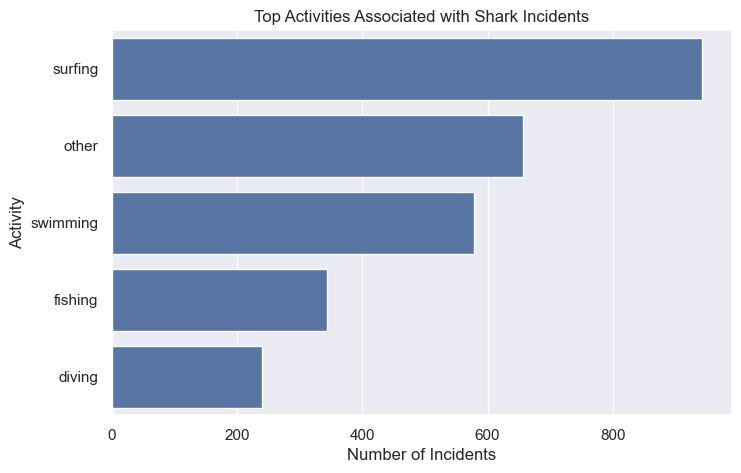

In [112]:
# Create bar plot for top activities
plt.figure(figsize=(8, 5))
sns.barplot(x=top_activities.values, y=top_activities.index)
plt.title("Top Activities Associated with Shark Incidents")
plt.xlabel("Number of Incidents")
plt.ylabel("Activity")

plt.show()

**Visualization Insight.** Surfing and swimming are the most common activities associated with shark incidents in recent data.

In [113]:
# Get top 10 countries
top_countries = df_recent["country"].value_counts().head(10)

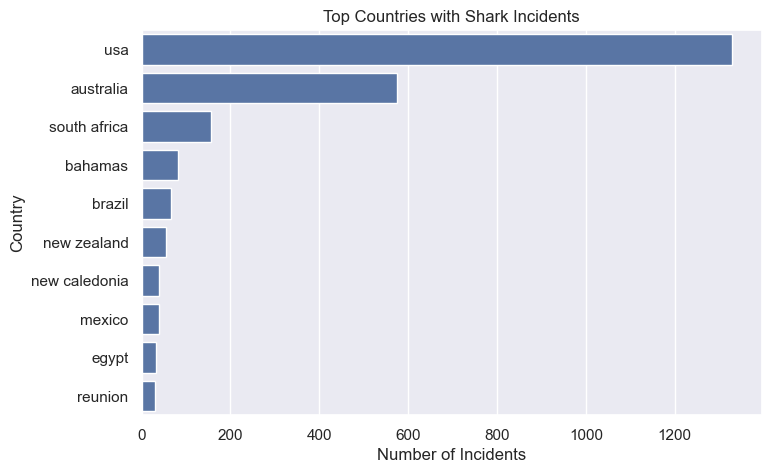

In [114]:
# Create bar plot for top countries
plt.figure(figsize=(8, 5))

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top Countries with Shark Incidents")
plt.xlabel("Number of Incidents")
plt.ylabel("Country")

plt.show()

**Visualization Insight.** Shark incidents are highly concentrated in a small number of countries, particularly the USA and Australia, indicating clear geographic hotspots.

In [115]:
# Create a crosstab for activity and injury
activity_injury = pd.crosstab(df_recent["activity_final"], df_recent["injury_final"])

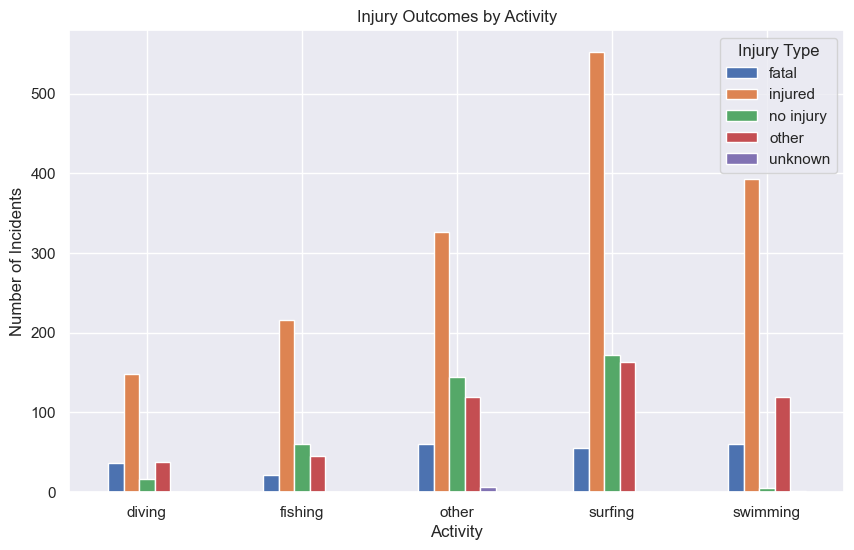

In [116]:
# Plot activity vs injury as grouped bar chart
activity_injury.plot(kind="bar", figsize=(10, 6))

plt.title("Injury Outcomes by Activity")
plt.xlabel("Activity")
plt.ylabel("Number of Incidents")
plt.legend(title="Injury Type")
plt.xticks(rotation=0)

plt.show()

**Visualization Insight.** Different activities show different risk profiles. Surfing has the highest number of incidents overall, while swimming shows a comparatively higher share of severe outcomes.

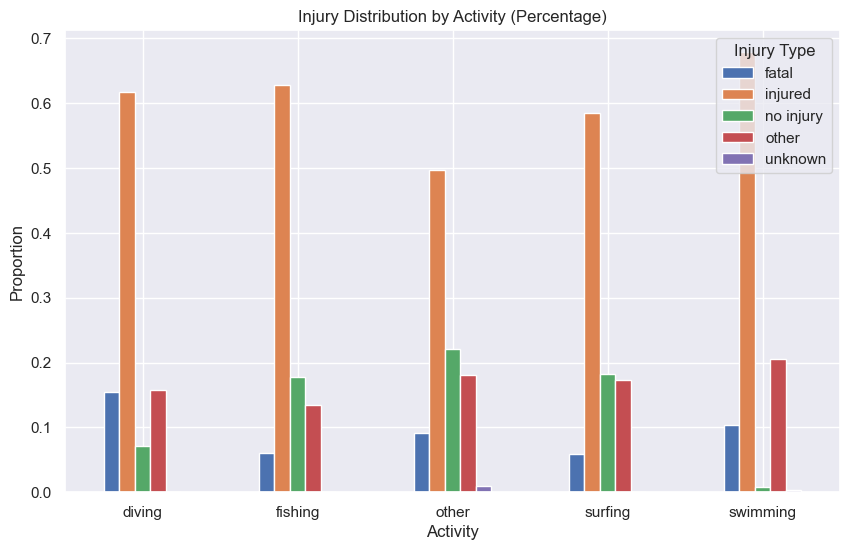

In [117]:
# Normalize to percentages
activity_injury_pct = activity_injury.div(activity_injury.sum(axis=1), axis=0)

activity_injury_pct.plot(kind="bar", figsize=(10,6))

plt.title("Injury Distribution by Activity (Percentage)")
plt.xlabel("Activity")
plt.ylabel("Proportion")
plt.legend(title="Injury Type")
plt.xticks(rotation=0)

plt.show()

**Visualization Insight.** When normalized, some activities show a higher relative risk of severe outcomes, even if total incident counts are lower.